In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
from IPython.display import clear_output, display
import time

In [97]:
learning_rate = 3e-4
batch_size = 32
epochs = 2
seed = 42
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed) 
    torch.cuda.manual_seed_all(seed)

Using mps device


In [117]:
train_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])

test_trasfrom = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])

training_data = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=train_transform
)

test_data = datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=test_trasfrom
)

training_dataloader = DataLoader(training_data, batch_size=32)
test_dataloader = DataLoader(test_data, batch_size=32)

torch.Size([32, 32, 3])
torch.Size([32, 32, 3])
torch.Size([32, 32, 3])
torch.Size([32, 32, 3])
torch.Size([32, 32, 3])
torch.Size([32, 32, 3])
torch.Size([32, 32, 3])
torch.Size([32, 32, 3])
torch.Size([32, 32, 3])
torch.Size([32, 32, 3])
torch.Size([32, 32, 3])
torch.Size([32, 32, 3])
torch.Size([32, 32, 3])
torch.Size([32, 32, 3])
torch.Size([32, 32, 3])
torch.Size([32, 32, 3])
torch.Size([32, 32, 3])
torch.Size([32, 32, 3])
torch.Size([32, 32, 3])
torch.Size([32, 32, 3])
torch.Size([32, 32, 3])
torch.Size([32, 32, 3])
torch.Size([32, 32, 3])
torch.Size([32, 32, 3])
torch.Size([32, 32, 3])
torch.Size([32, 32, 3])
torch.Size([32, 32, 3])
torch.Size([32, 32, 3])
torch.Size([32, 32, 3])
torch.Size([32, 32, 3])
torch.Size([32, 32, 3])
torch.Size([32, 32, 3])


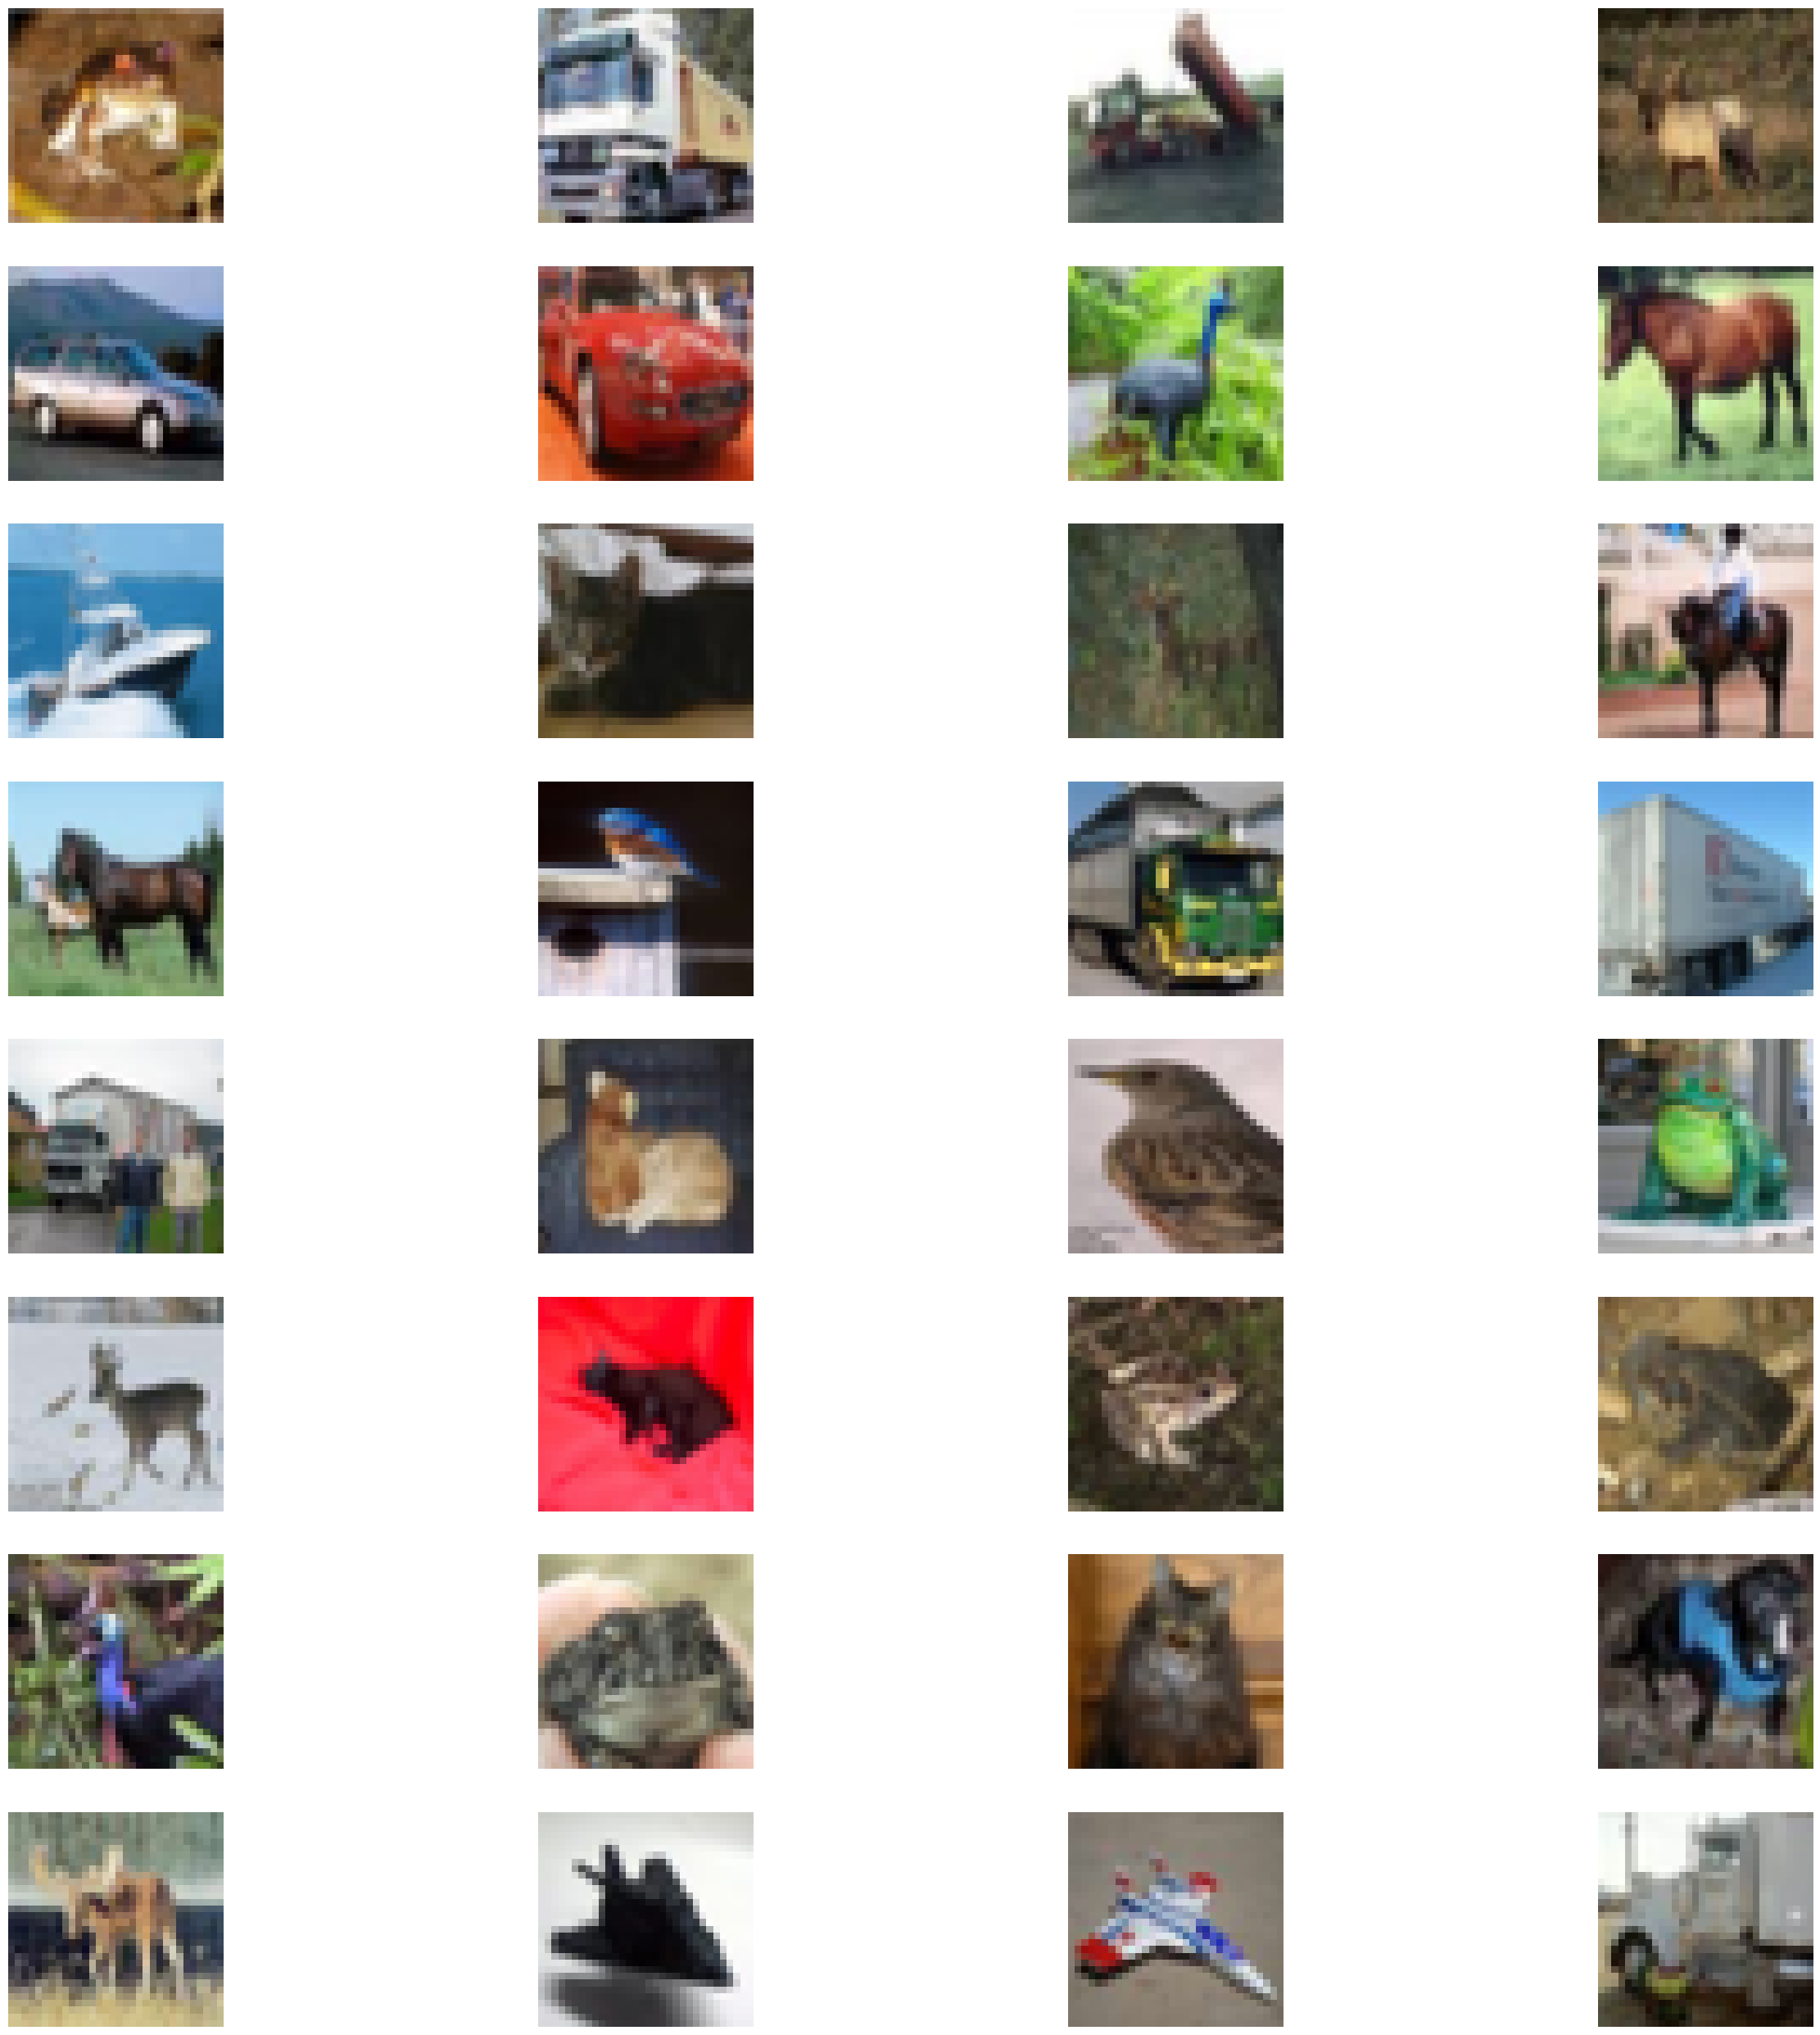

In [47]:
fig, axes = plt.subplots(8, 4, figsize=(32, 32)) 
axes = axes.flatten()

for i in range(32):
    img,_ = training_data[i]
    img = img.permute(1,2,0)
    axes[i].imshow(img)
    axes[i].axis('off')
    print(img.shape)
for i in range(32, len(axes)):
    axes[i].axis('off')

torch.Size([3, 4, 4, 8, 8])
torch.Size([16, 8, 8, 3])


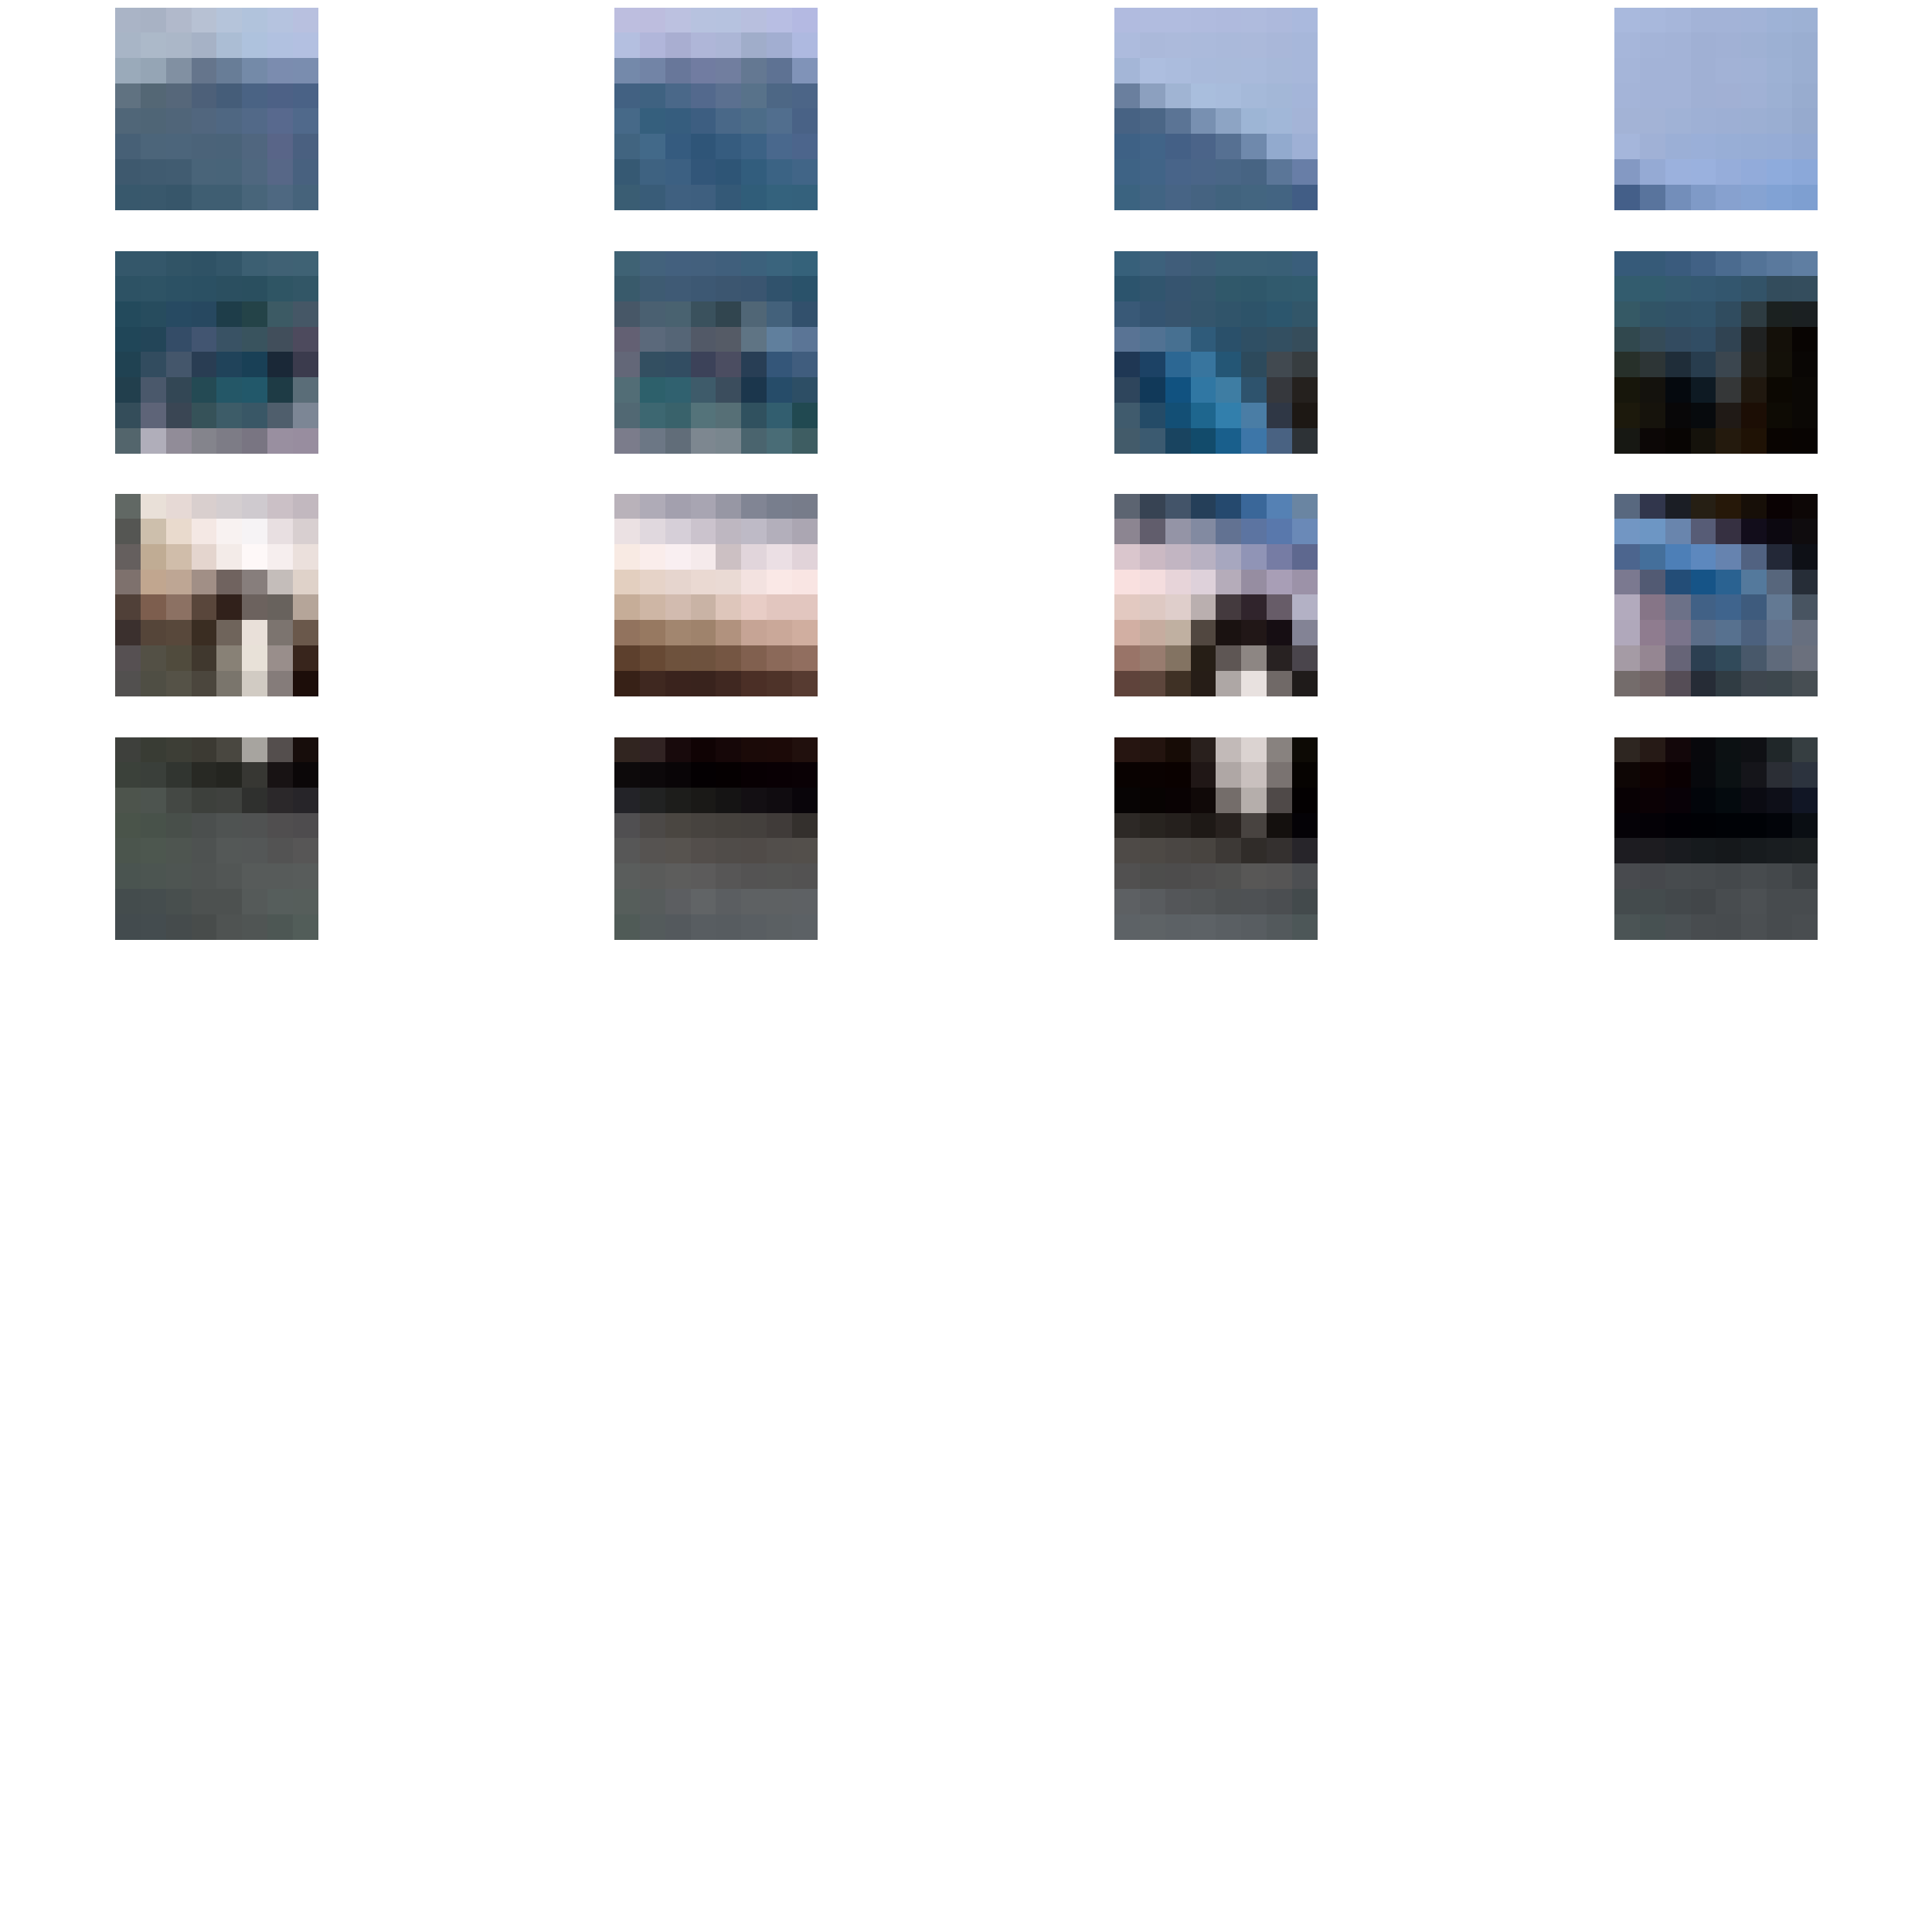

In [59]:
img,_ = training_data[4]

patch_size=8
patches = img.unfold(1, patch_size, patch_size)\
             .unfold(2, patch_size, patch_size)

print(patches.shape)
patches = patches.permute(1, 2, 3, 4, 0)
patches = patches.reshape(-1, patch_size, patch_size, 3)
print(patches.shape)

fig, axes = plt.subplots(8, 4, figsize=(32, 32)) 
axes = axes.flatten()

for i in range(16):
    axes[i].imshow(patches[i])
    axes[i].axis('off')
for i in range(16, len(axes)):
    axes[i].axis('off')

In [60]:
img,_ = training_data[4]

patch_size=8
patches = img.unfold(1, patch_size, patch_size)\
             .unfold(2, patch_size, patch_size)

print(patches.shape)
patches = patches.permute(1, 2, 0, 3, 4)
patches = patches.reshape(-1, 3, patch_size, patch_size)
print(patches.shape)

torch.Size([3, 4, 4, 8, 8])
torch.Size([16, 3, 8, 8])


In [61]:
tokens = patches.flatten(start_dim=1)
tokens.shape

torch.Size([16, 192])

In [77]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=8, in_channels=3, embed_dim=123):
        super().__init__()
        self.img_size = img_size
        self.patch_size=patch_size
        self.num_patches = (img_size//patch_size)**2

        self.proj = nn.Conv2d(
            in_channels=in_channels,
            out_channels=embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches + 1, embed_dim))

    def forward(self, x):
        B, C, H, W = x.shape

        x = self.proj(x)
        x = x.flatten(2)
        x = x.transpose(1, 2)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        return x

In [78]:
patch_embedding = PatchEmbedding()
x = torch.randn(1, 3, 32, 32)
z = patch_embedding(x)
print(x.shape)
print(z.shape)

torch.Size([1, 3, 32, 32])
torch.Size([1, 17, 123])


In [84]:
class Attention(nn.Module):
    def __init__(self, embed_dim=123, qkv_bias=False, num_heads=3):
        super().__init__()
        self.embed_dim=embed_dim
        self.qkv_bias=qkv_bias
        self.num_heads=num_heads
        self.head_dim = embed_dim // num_heads

        self.scale = self.head_dim ** -0.5
        self.Uqkv = nn.Linear(embed_dim, embed_dim*3, bias=qkv_bias)
        self.proj = nn.Linear(embed_dim, embed_dim)
    
    def forward(self, x):
        B, N, C = x.shape
        qkv = self.Uqkv(x)  #dim: B, N, C * 3

        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) / self.scale
        attn = attn.softmax(dim=-1)

        x = attn @ v

        x = x.transpose(1, 2)
        x = x.reshape(B, N, C)

        x = self.proj(x)

        return x


In [85]:
attention = Attention()
y = attention(z)
print(y.shape)

torch.Size([1, 17, 123])


In [87]:
class MLP(nn.Module):
    def __init__(self,input_dim=123, mlp_ratio=4.0):
        super().__init__()
        hidden_dim = (int)(input_dim*mlp_ratio)
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        x = F.gelu(self.fc1(x))
        x = self.fc2(x)
        return x

In [90]:
x = torch.randn(1, 17, 123)
mlp = MLP()
y = mlp(x)
print(y.shape)

torch.Size([1, 17, 123])


In [100]:
class EncoderBlock(nn.Module):
    def __init__(self, embed_dim=123, num_heads=3, qkv_bias=False, mlp_ratio=4.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.attn = Attention(embed_dim=embed_dim, qkv_bias=qkv_bias, num_heads=num_heads)
        self.mlp = MLP(input_dim=embed_dim, mlp_ratio=mlp_ratio)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


In [101]:
x = torch.randn(1, 17, 123)
ebl = EncoderBlock()
y = ebl(x)
print(y.shape)

torch.Size([1, 17, 123])


In [102]:
class Encoder(nn.Module):
    def __init__(self, depth=12, embed_dim=123, num_heads=3, qkv_bias=False, mlp_ratio=4.0):
        super().__init__()
        self.blocks = nn.ModuleList([
            EncoderBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                qkv_bias=qkv_bias,
                mlp_ratio=mlp_ratio
            )
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        return x

In [103]:
x = torch.randn(1, 17, 123)
enc = Encoder()
y = enc(x)
print(y.shape)

torch.Size([1, 17, 123])


In [104]:
class Decoder(nn.Module):
    def __init__(self, embed_dim=123, classes=10):
        super().__init__()
        self.fc = nn.Linear(embed_dim, classes, bias=False)
    def forward(self, x):
        return self.fc(x)

In [108]:
def train_loop(dataloader, model, loss_fn, optimizer, loss_values):
    size = len(dataloader.dataset)
    model.to(device)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        loss_values.append(loss.item())

        if batch % 100 == 0:
            loss, curr = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f} [{curr:>5d}/{size:>5d}]")


def test_loop(dataloader, model, loss_fn, error_rates):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred=model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    error_rates.append(1-correct)
    print(f"Test Error: \n Accuracy: {(100*correct)::>0.1f}%, Avg loss: {test_loss:>8f} \n")


In [98]:
training_data.targets = [1] * len(training_data)
test_data.targets = [1] * len(test_data)

independent_training_dataloader = DataLoader(
    training_data,
    batch_size=32
)

independent_test_dataloader = DataLoader(
    test_data,
    batch_size=32
)

In [110]:
class VisionTransformer(nn.Module):
    def __init__(self,img_size=32, patch_size=8, in_channels=3, embed_dim=123,depth=32, num_heads=3, qkv_bias=False, mlp_ratio=4.0, num_classes=10):
        super().__init__()
        self.patch_embed = PatchEmbedding(
            img_size=img_size,
            patch_size=patch_size,
            in_channels=in_channels,
            embed_dim=embed_dim
        )
        self.enc = Encoder(
            depth=depth,
            embed_dim=embed_dim,
            num_heads=num_heads,
            qkv_bias=qkv_bias,
            mlp_ratio=mlp_ratio
        )
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )
    def forward(self, x):
        x = self.patch_embed(x)
        x = self.enc(x)
        cls_token_out = x[:, 0]
        logits = self.mlp_head(cls_token_out)
        return logits

In [112]:
loss_fn = nn.CrossEntropyLoss()
baseline_model = VisionTransformer()
optimizer = torch.optim.Adam(baseline_model.parameters(), lr=learning_rate)
input_independent_losses = []
input_independent_error_rates = []

train_loop(independent_training_dataloader, baseline_model, loss_fn, optimizer, input_independent_losses)
test_loop(independent_test_dataloader, baseline_model, loss_fn, input_independent_error_rates)

loss: 2.891336 [   32/50000]
loss: 0.005070 [ 3232/50000]
loss: 0.002301 [ 6432/50000]
loss: 0.001305 [ 9632/50000]
loss: 0.000845 [12832/50000]
loss: 0.000591 [16032/50000]
loss: 0.000438 [19232/50000]
loss: 0.000338 [22432/50000]
loss: 0.000268 [25632/50000]
loss: 0.000216 [28832/50000]
loss: 0.000178 [32032/50000]
loss: 0.000150 [35232/50000]
loss: 0.000128 [38432/50000]
loss: 0.000109 [41632/50000]
loss: 0.000094 [44832/50000]
loss: 0.000083 [48032/50000]
Test Error: 
 Accuracy: 100.0%, Avg loss: 0.000076 



#1: loss: 2.5645347; acc: 0.0625
#2: loss: 2.1925209; acc: 0.1875
#3: loss: 2.1165347; acc: 0.3750
#4: loss: 1.9505677; acc: 0.1875
#5: loss: 1.9114463; acc: 0.2500
#6: loss: 1.8959689; acc: 0.3125
#7: loss: 1.7891322; acc: 0.5000
#8: loss: 1.6932340; acc: 0.5625
#9: loss: 1.6733096; acc: 0.5625
#10: loss: 1.6567739; acc: 0.5625
#11: loss: 1.5903316; acc: 0.5000
#12: loss: 1.4958136; acc: 0.5000
#13: loss: 1.4462748; acc: 0.6250
#14: loss: 1.3201077; acc: 0.6875
#15: loss: 1.1848967; acc: 0.8125
#16: loss: 1.0675752; acc: 0.8750
#17: loss: 0.9042670; acc: 0.9375
#18: loss: 0.7271916; acc: 0.9375
#19: loss: 0.5750405; acc: 1.0000
#20: loss: 0.4853567; acc: 0.9375
#21: loss: 0.3388133; acc: 1.0000
#22: loss: 0.2481382; acc: 1.0000
#23: loss: 0.2478443; acc: 1.0000
#24: loss: 0.1806817; acc: 1.0000
#25: loss: 0.1587009; acc: 1.0000
#26: loss: 0.1353188; acc: 1.0000
#27: loss: 0.1438589; acc: 1.0000
#28: loss: 0.1382876; acc: 1.0000
#29: loss: 0.1411081; acc: 1.0000
#30: loss: 0.1393299; a

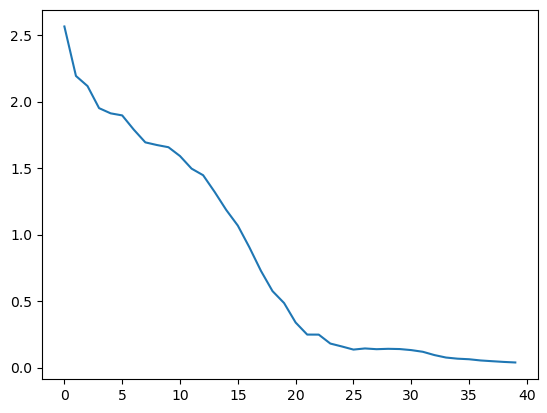

In [125]:
fixed_training_dataloader = DataLoader(training_data, batch_size=16)

fixed_batch = next(iter(fixed_training_dataloader))
fixed_batch_model = VisionTransformer()
fixed_batch_losses=[]

X, y = fixed_batch
X, y = X.to(device), y.to(device)
fixed_batch_model.to(device)
fixed_batch_optimizer = torch.optim.Adam(fixed_batch_model.parameters(), lr=learning_rate)
for i in range(40):
    fixed_batch_optimizer.zero_grad()

    pred = fixed_batch_model(X)
    loss = loss_fn(pred, y)
    fixed_batch_losses.append(loss.item())
    
    loss.backward()
    fixed_batch_optimizer.step()

    acc = (pred.argmax(1) == y).float().mean()
    print(f"#{i+1}: loss: {loss.item():.7f}; acc: {acc:.4f}")


plt.plot(fixed_batch_losses)